# Notebook 14 — Publication Figures and Tables

## Purpose
I generate clean, publication-quality versions of all key figures.
These are the figures used directly in the report and any presentations.

## Outputs
All saved to `reports/figures/` and `paper_or_report/figures/`


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.insert(0, str(Path('..').resolve()))
from src.config import load_config
from src.paths import Paths
from src.visualization import save_fig

cfg   = load_config()
paths = Paths(cfg)

master = pd.read_parquet(paths.processed / cfg['data']['master_file'])
rfm    = pd.read_parquet(paths.processed / cfg['data']['rfm_file'])
print("Data loaded.")

# Set publication style
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
})


Data loaded.


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\fig1_monthly_revenue_orders.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\fig1_monthly_revenue_orders.png


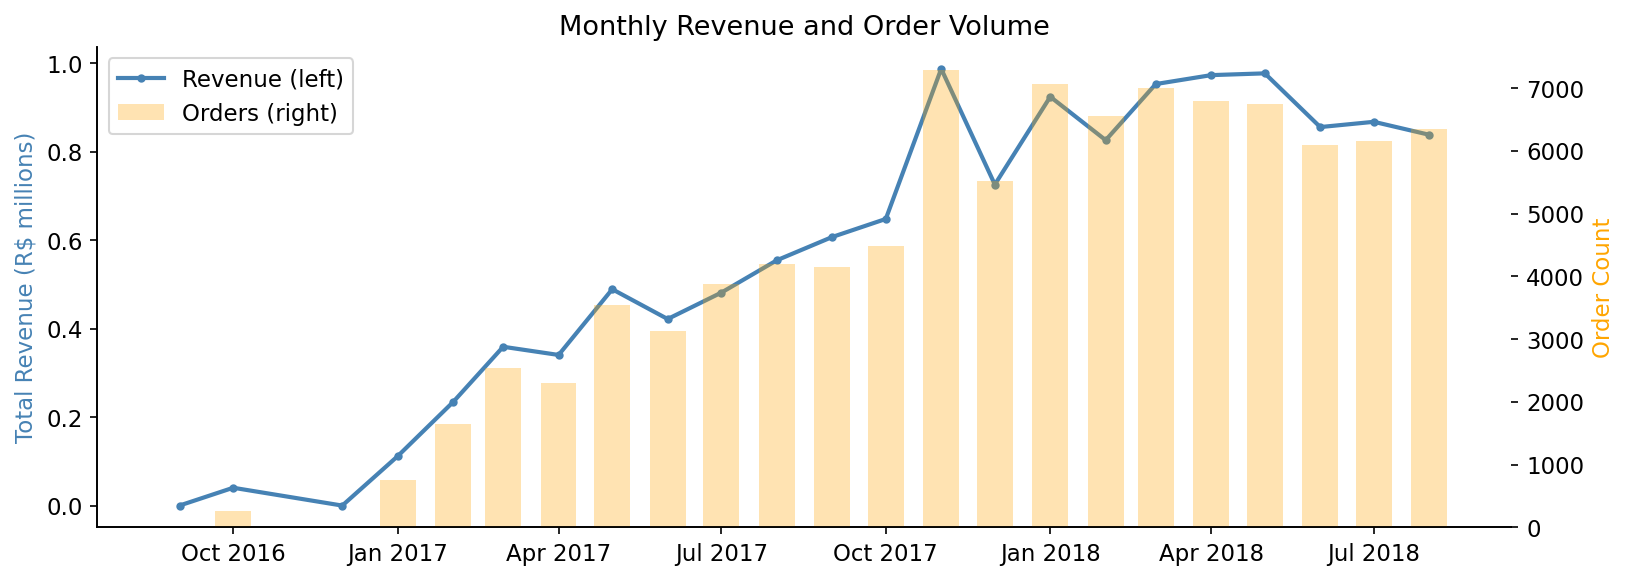

In [2]:
# Figure 1: Monthly revenue + order count (dual axis)
master['month'] = master['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
monthly = master.groupby('month').agg(
    revenue=('order_value', 'sum'),
    orders=('order_id', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()
ax1.plot(monthly['month'], monthly['revenue']/1e6, color='steelblue',
         marker='o', markersize=3, linewidth=2, label='Revenue (left)')
ax2.bar(monthly['month'], monthly['orders'], alpha=0.3, color='orange',
        width=20, label='Orders (right)')
ax1.set_ylabel('Total Revenue (R$ millions)', color='steelblue')
ax2.set_ylabel('Order Count', color='orange')
ax1.set_title('Monthly Revenue and Order Volume')
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
save_fig(fig, 'fig1_monthly_revenue_orders',
         reports_dir=str(paths.reports_figs), paper_dir=str(paths.paper_figs))
plt.show(); plt.close()


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\fig2_segment_revenue_pareto.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\fig2_segment_revenue_pareto.png


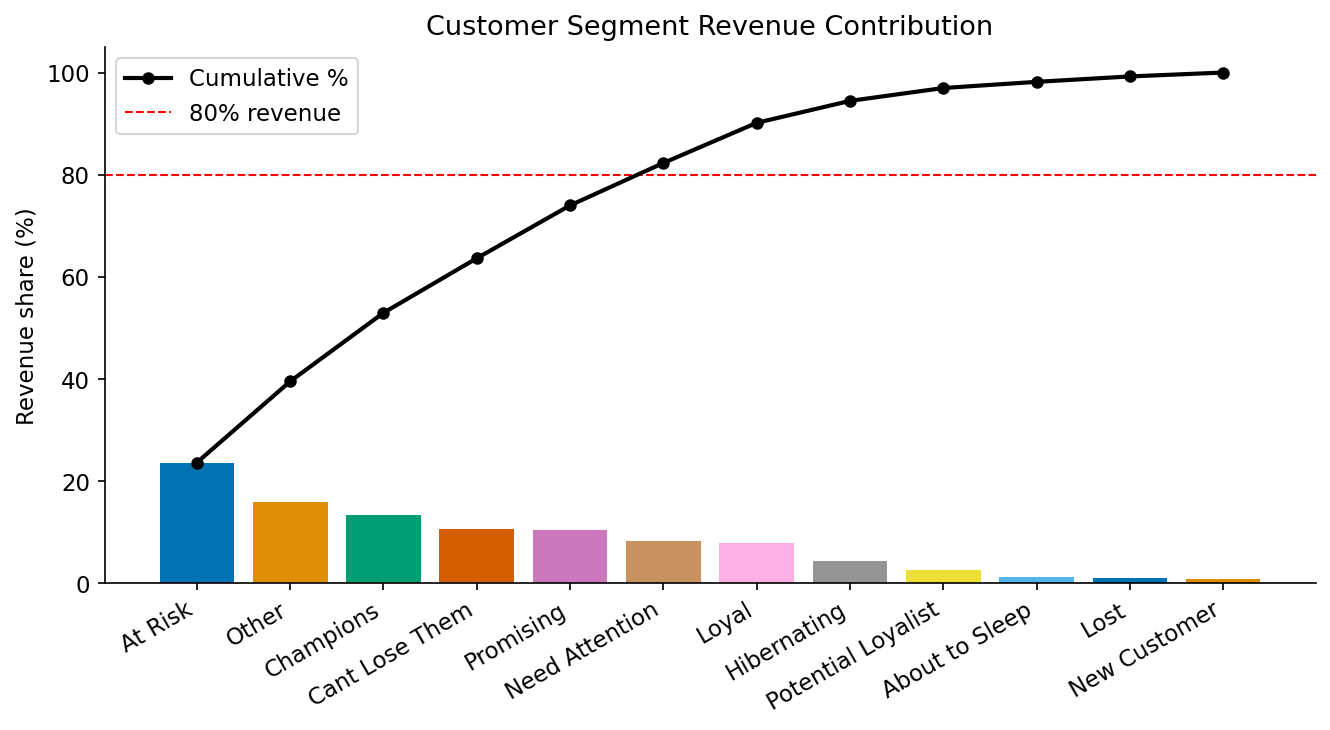

In [3]:
# Figure 2: Segment revenue contribution (Pareto-style)
seg_rev = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)
seg_rev_pct = seg_rev / seg_rev.sum() * 100
cumulative = seg_rev_pct.cumsum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(seg_rev_pct.index, seg_rev_pct.values,
              color=sns.color_palette('colorblind', len(seg_rev_pct)))
ax.plot(range(len(cumulative)), cumulative.values, 'ko-', linewidth=2,
        markersize=5, label='Cumulative %', zorder=5)
ax.axhline(80, color='red', linestyle='--', linewidth=1, label='80% revenue')
ax.set_ylabel('Revenue share (%)')
ax.set_title('Customer Segment Revenue Contribution')
plt.xticks(range(len(seg_rev_pct)), seg_rev_pct.index, rotation=30, ha='right')
ax.legend()
plt.tight_layout()
save_fig(fig, 'fig2_segment_revenue_pareto',
         reports_dir=str(paths.reports_figs), paper_dir=str(paths.paper_figs))
plt.show(); plt.close()


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\fig3_review_by_delay_bucket.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\fig3_review_by_delay_bucket.png


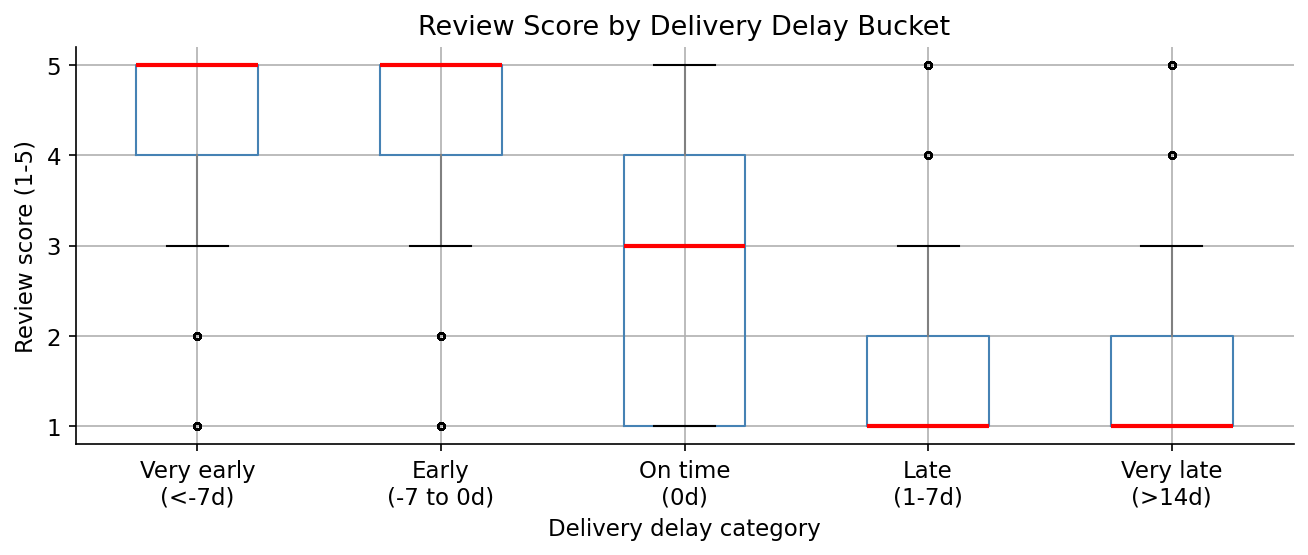

In [4]:
# Figure 3: Delivery delay vs review score (box plot)
valid = master.dropna(subset=['delivery_delay_days', 'review_score']).copy()
valid['delay_bin'] = pd.cut(
    valid['delivery_delay_days'].clip(-15, 30),
    bins=[-15, -7, 0, 7, 14, 30],
    labels=['Very early\n(<-7d)', 'Early\n(-7 to 0d)',
            'On time\n(0d)', 'Late\n(1-7d)', 'Very late\n(>14d)']
)

fig, ax = plt.subplots(figsize=(9, 4))
valid.boxplot(column='review_score', by='delay_bin', ax=ax,
              boxprops=dict(color='steelblue'),
              medianprops=dict(color='red', linewidth=2),
              whiskerprops=dict(color='grey'),
              flierprops=dict(alpha=0.2, markersize=3))
ax.set_title('Review Score by Delivery Delay Bucket')
ax.set_xlabel('Delivery delay category')
ax.set_ylabel('Review score (1-5)')
plt.suptitle('')
plt.tight_layout()
save_fig(fig, 'fig3_review_by_delay_bucket',
         reports_dir=str(paths.reports_figs), paper_dir=str(paths.paper_figs))
plt.show(); plt.close()


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\fig4_state_revenue_vs_late_rate.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\fig4_state_revenue_vs_late_rate.png


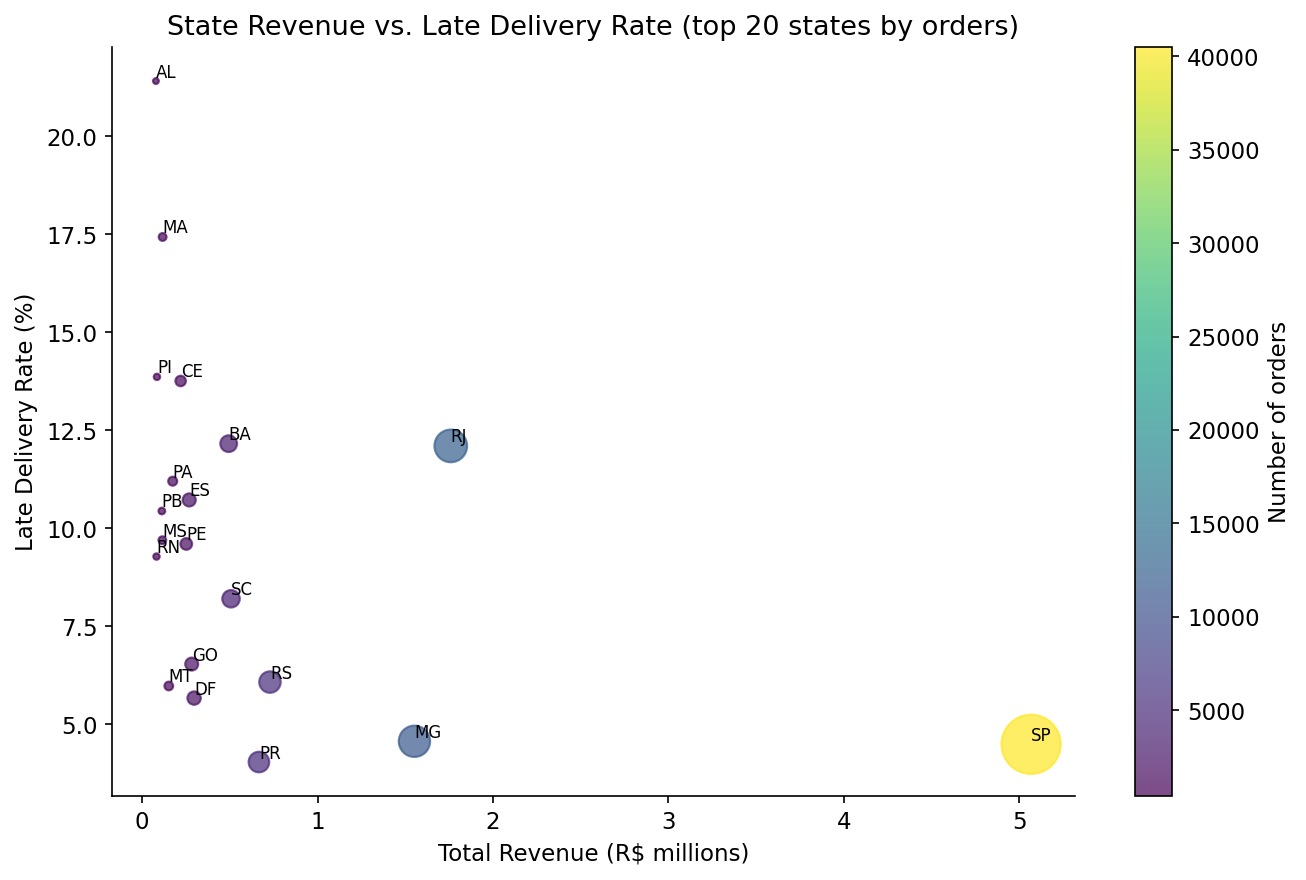

All publication figures generated.


In [5]:
# Figure 4: Top 10 states — revenue vs late rate scatter
state_stats = master.groupby('customer_state').agg(
    revenue=('order_value', 'sum'),
    late_rate=('is_late', 'mean'),
    n_orders=('order_id', 'count'),
).reset_index()
top_states = state_stats.nlargest(20, 'n_orders')

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    top_states['revenue']/1e6,
    top_states['late_rate']*100,
    s=top_states['n_orders']/50,
    c=top_states['n_orders'], cmap='viridis', alpha=0.7
)
plt.colorbar(scatter, ax=ax, label='Number of orders')
for _, row in top_states.iterrows():
    ax.annotate(row['customer_state'],
                (row['revenue']/1e6, row['late_rate']*100),
                fontsize=8, ha='left', va='bottom')
ax.set_xlabel('Total Revenue (R$ millions)')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('State Revenue vs. Late Delivery Rate (top 20 states by orders)')
plt.tight_layout()
save_fig(fig, 'fig4_state_revenue_vs_late_rate',
         reports_dir=str(paths.reports_figs), paper_dir=str(paths.paper_figs))
plt.show(); plt.close()
print("All publication figures generated.")
